# GeoCareTool — Thimphu, Bhutan

End-to-end demonstration of the **GeoCareTool** package, applied to Thimphu (capital of Bhutan). 


By the end of this notebook you will have:

1. **Inventoried care facilities** in a city by querying the **Google Places API** over a regular spatial grid, with a *pre-run cost estimate* so you know what the scrape will cost before you press play.
2. Built **walking isochrones** (areas reachable on foot in 20 minutes) around each facility using the OpenStreetMap pedestrian network.
3. Built a **synthetic GTFS** feed for public transport when no official feed exists, and used it to compute a **household → facility travel-time matrix** with `r5py`.
4. Combined demand, walking access, and PT access to classify **care deserts** — and broken them down by demographic group (children, elderly, persons with disability).

## Pipeline overview

```
   ┌────────────┐   ┌────────────┐   ┌─────────────────┐   ┌──────────────┐
   │  Scraping  │ → │ Facilities │ → │  Accessibility  │ → │ Care deserts │
   │ (Places)   │   │ (geo pts)  │   │ (walk + PT)     │   │ (by group)   │
   └────────────┘   └────────────┘   └─────────────────┘   └──────────────┘
        §1               §1                  §4                    §5
```

> The notebook is **not executed** by default — paths and a Google API key must be filled in first. The cells are runnable top-to-bottom once those are set.

## Prerequisites

- A Google Cloud project with the **Places API enabled** and an API key in `GOOGLE_API_KEY` (in `.env` or shell).
- Python env with `geopandas`, `googlemaps`, `osmnx`, `r5py`, `contextily`, `python-dotenv`.
- Demand and (optional) transport input data for the city — examples linked in the relevant sections.


## 0 · Setup

We import what the whole notebook will need, load secrets from `.env`, create the output folder structure, and define two **project-wide constants**:

- **`THIMPHU_BBOX`** — a rectangle in latitude/longitude that contains the city. Everything we scrape and analyse is clipped to (or seeded inside) this box.
- **`GRID_STEP_M`** — spacing of our scraping grid, in **metres**. Smaller step = more thorough coverage but exponentially more API calls.


Geographic work needs two coordinate systems:

| CRS | Used for | Notes |
| --- | --- | --- |
| **`EPSG:4326`** (WGS84, lat/lng) | Storage, input/output, web maps | Units are **degrees** — you can't measure distance reliably in degrees |
| **`EPSG:32646`** (UTM 46N) | Distance, buffers, area | Units are **metres** — pick the UTM zone that covers your city |

For other cities, change `METRIC_CRS` to the appropriate UTM zone (e.g. `EPSG:32618` for Bogotá, `EPSG:32617` for Panama City).


In [9]:
import os
from pathlib import Path
from datetime import datetime

import pandas as pd
import geopandas as gpd
from dotenv import load_dotenv

load_dotenv()   # reads a local .env file if present

# Project paths — adjust to your local layout
ROOT = Path("./thimphu_outputs")
(ROOT / "scraping").mkdir(parents=True, exist_ok=True)
(ROOT / "accessibility").mkdir(parents=True, exist_ok=True)
(ROOT / "care_deserts").mkdir(parents=True, exist_ok=True)

# Thimphu bounding box (approx., WGS84)
THIMPHU_BBOX = {
    "min_lat": 27.40,
    "max_lat": 27.55,
    "min_lng": 89.58,
    "max_lng": 89.72,
}
GRID_STEP_M = 1500   # ~1.5 km grid spacing
GEO_CRS = "EPSG:4326"
METRIC_CRS = "EPSG:32646"   # UTM zone 46N — covers Bhutan

## 1 · Web scraping — Google Places (care facilities in Thimphu)

We don't have a clean registry of care facilities in Thimphu, so we **build one from Google Places**. Three pieces:

1. **A grid of search centres** that tiles the bounding box (`generate_grid`).
   The Places `nearbysearch` endpoint only searches *around a point*, so to cover a whole city we query many points.
2. **Per-cell queries** for every keyword we care about (`fetch_places`).
   Each call returns up to 60 results within `step_size` metres of the centre.
3. **Concatenate + deduplicate** the results across all (cell × keyword) calls, using `place_id` as the unique key.

### Key idea: grid spacing vs. search radius

We set `step_size = GRID_STEP_M`, so each grid cell's search radius equals the spacing — neighbouring cells just touch. **Overlap is intentional**: a facility near the edge of one cell will also appear in the neighbouring cell's results, which is why deduplication by `place_id` matters.

### `generate_grid(min_lat, max_lat, min_lng, max_lng, step)`

Returns a list of `(lat, lng)` tuples. It converts the metric `step` into degrees using the Earth's radius and the **latitude-dependent** longitude scaling (a degree of longitude is shorter near the poles than at the equator).

### `plot_grid_with_basemap(...)`

Sanity-check: shows the grid points on top of a basemap so you can see whether your bounding box actually covers the city.


Grid points to query: 120


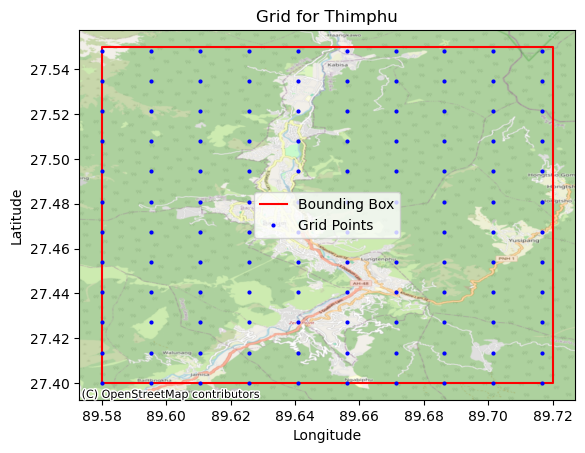

In [10]:
from GeoCareTool.GPlaces_Scraping.scraper import (
    generate_grid,
    plot_grid_with_basemap,
    fetch_places,
    load_and_concatenate_files,
    estimate_cost,
    print_cost_estimate,
)

GOOGLE_API_KEY = os.environ["GOOGLE_API_KEY"]   # set in .env or shell: export GOOGLE_API_KEY=...

grid = generate_grid(
    THIMPHU_BBOX["min_lat"], THIMPHU_BBOX["max_lat"],
    THIMPHU_BBOX["min_lng"], THIMPHU_BBOX["max_lng"],
    step=GRID_STEP_M,
)
print(f"Grid points to query: {len(grid)}")

# Optional: visualize the grid over a basemap
plot_grid_with_basemap(
    "Thimphu", grid,
    bounding_box=(
        THIMPHU_BBOX["min_lat"], THIMPHU_BBOX["max_lat"],
        THIMPHU_BBOX["min_lng"], THIMPHU_BBOX["max_lng"],
    ),
)

### Cost estimate (before scraping) — *the most important cell in this section*

Scraping a city is **not free**. Before you run the loop, you need to know roughly what it will cost.

#### Pricing reality check (2026)

- Google Places **Nearby Search**, base tier: **$0.032 per request** (= $32 per 1,000).
- Above 100k requests/month it drops to $0.0256/request on the legacy API.
- The new Places API tiers further down at high volume.
- Every billing account gets **5,000 free Nearby Search requests/month** and a **$200/month** Maps Platform credit.

#### What drives total cost

```
requests ≈ (grid points) × (number of keywords) × pagination_factor
cost     ≈ requests × $0.032   (minus free tier)
```

- **Grid points**: doubling the area of your bounding box doubles the grid. Halving `GRID_STEP_M` *quadruples* it.
- **Keywords**: every entry in every category list is a separate API call per grid cell.
- **`pagination_factor`**: `fetch_places` follows `next_page_token` up to two times when a cell returns >20 results, so the **worst case is 3.0**. Use ~1.0 in rural areas, 1.5–2.0 in dense urban areas, 3.0 worst case.

#### `estimate_cost(...)`

Lives in `scraper.py`. Returns a dict with `requests_min / requests_expected / requests_max` and matching `cost_*` figures, plus a tidy printout via `print_cost_estimate`.

The `assert` below is a **hard safety cap**: if the worst-case cost exceeds `BUDGET_USD`, the cell will raise and stop you from running the scrape. Tune the budget and the pagination factor before you continue.


In [11]:
KEYWORDS = {
    "childcare":       ["daycare", "creche", "early childhood center", "kindergarten"],
    "elderly_care":    ["elderly care", "old age home", "senior care"],
    "disability_care": ["disability center", "special needs school", "rehabilitation center"],
    "health":          ["hospital", "clinic", "basic health unit"],
}

estimate = estimate_cost(
    num_grid_points=len(grid),
    keywords=KEYWORDS,
    cost_per_request=0.032,   # $32 / 1000 — Google Places Nearby Search base tier (2026)
    pagination_factor=1.5,    # bump to 2.0–3.0 for dense urban areas
    free_tier=5000,           # Google Pro SKU free monthly tier
)
print_cost_estimate(estimate)

# Safety cap — abort the scrape if the worst-case cost exceeds this
BUDGET_USD = 50.0
assert estimate["cost_max"] <= BUDGET_USD, (
    f"Worst-case cost ${estimate['cost_max']:.2f} exceeds BUDGET_USD=${BUDGET_USD}. "
    "Increase BUDGET_USD or reduce grid/keywords."
)

Google Places Nearby Search — cost estimate (@ $0.0320/request)
  Grid points x keywords:   120 x 13
  Requests (min/exp/max):   1,560 / 2,340 / 4,680
  Cost USD (min/exp/max):   $0.00 / $0.00 / $0.00


### Running the scrape

Once the cost is acceptable, run the loop below. For every **category** (e.g. `childcare`), for every **keyword** in that category (e.g. `daycare`, `creche`...), and for every **grid point**, we call `fetch_places` and accumulate the results.

#### `fetch_places(lat, lng, keyword, key, step_size)`

Thin wrapper around `googlemaps.Client.places_nearby`. It:

- Sets `radius = step_size` (metres) around `(lat, lng)`.
- Filters by `keyword` (a free-text match against name + types).
- **Follows `next_page_token`** up to 2 more times — Google paginates results 20 at a time, max 60. Includes a `time.sleep(2)` between pages because the token isn't valid immediately.
- Returns a `pd.DataFrame` of `place_id, name, lat, lng, types, ...` via the `base_chica` helper.
- On any exception, returns an **empty DataFrame** so the outer loop keeps going.

#### After the loop

- One pickle file per category in `thimphu_outputs/scraping/{category}_thimphu.pkl`.
- Deduplication is done **within each category** via `drop_duplicates("place_id")`. A facility tagged by two keywords in the same category counts once. The same facility found under two *different* categories will appear twice (intentional — we care about both interpretations).


In [ ]:
scraped = {}
for category, kw_list in KEYWORDS.items():
    dfs = []
    for kw in kw_list:
        for lat, lng in grid:
            df = fetch_places(lat, lng, keyword=kw, key=GOOGLE_API_KEY, step_size=GRID_STEP_M)
            if not df.empty:
                df["keyword"] = kw
                df["category"] = category
                dfs.append(df)
    if dfs:
        out = pd.concat(dfs, ignore_index=True).drop_duplicates("place_id")
        out.to_pickle(ROOT / "scraping" / f"{category}_thimphu.pkl")
        scraped[category] = out
        print(f"{category}: {len(out):,} unique places")

### Consolidating into a single GeoDataFrame

`load_and_concatenate_files` globs all `*_thimphu.pkl` files we just wrote and concatenates them into one DataFrame. We then promote it to a **`GeoDataFrame`**:

- `geometry = points_from_xy(lng, lat)` — turns the lat/lng columns into proper `shapely.Point` geometries.
- `crs="EPSG:4326"` — declares those coordinates are WGS84.
- Save as **GeoPackage** (`.gpkg`) — a modern, single-file alternative to Shapefile that handles long column names, UTF-8, and multiple layers cleanly.

`facilities` is the **supply layer** that the rest of the notebook uses (isochrones, TTM, deserts).


In [ ]:
# Consolidate all categories into one GeoDataFrame of supply points
all_places = load_and_concatenate_files(str(ROOT / "scraping" / "*_thimphu.pkl"))
facilities = gpd.GeoDataFrame(
    all_places,
    geometry=gpd.points_from_xy(all_places["lng"], all_places["lat"]),
    crs=GEO_CRS,
)
facilities.to_file(ROOT / "scraping" / "facilities_thimphu.gpkg", driver="GPKG")
print(f"Total facilities (all categories): {len(facilities):,}")
facilities.head()

## 2 · Data cleaning

The raw §1 output mixes real care facilities with **false positives** — pharmacies, hotels, restaurants and other places Google's keyword search picked up by accident. Before we pay for Place Details enrichment (§3) we filter the list down.

The `preprocessing` module is **standalone** — no ML model, no vectorizers — just deterministic steps you can read and audit:

| Step | What it does |
| --- | --- |
| `parse_types` | Coerce the `types` column to a real `list[str]` no matter how it was serialised |
| `normalize_name` | Add a lowercase, accent-stripped `name_clean` column for fuzzy work |
| `filter_by_types` | Keep only rows whose Google `types` intersect a whitelist |
| `filter_by_name` | Drop rows whose name matches a blacklist regex (pharmacies, vets…) |
| `deduplicate` | One row per `place_id`, keeping the most-complete copy |

`preprocess(...)` wires them together. Defaults are conservative — review the row-count diagnostics and adjust `keep_types` / `name_blacklist` for your city.


In [ ]:
from GeoCareTool.DataCleaning.preprocessing import (
    preprocess,
    TYPE_WHITELISTS,
    DEFAULT_NAME_BLACKLIST,
)

# Inspect what the defaults will keep / drop before running
print("Type whitelist for 'children':", sorted(TYPE_WHITELISTS["children"]))
print("Name blacklist regex:", DEFAULT_NAME_BLACKLIST.pattern)

# Run the pipeline. `population` picks a starter type whitelist;
# override with `keep_types=["hospital", "school", ...]` for full control.
cleaned = preprocess(
    facilities,
    population="general_care",   # one of: children / disability / older_adults / general_care
    name_blacklist=DEFAULT_NAME_BLACKLIST,
    add_type_dummies=False,
    verbose=True,                  # prints row counts after every step
)

# Save the kept list — §3 (Extra downloads) reads this file by default.
cleaned.drop(columns="geometry", errors="ignore").to_csv(
    ROOT / "scraping" / "facilities_kept.csv",
    index=False,
)
print(f"\nFacilities kept: {len(cleaned):,} of {len(facilities):,}")
cleaned.head()

### Review and iterate

Open `facilities_kept.csv` in QGIS or a spreadsheet and spot-check. If you see false positives left over, two ways to tighten:

```python
# 1. Add words to the name blacklist
import re
my_blacklist = re.compile(DEFAULT_NAME_BLACKLIST.pattern + r"|\b(spa|salon|tienda)\b", re.IGNORECASE)

# 2. Or pass your own type whitelist explicitly
cleaned = preprocess(
    facilities,
    keep_types=["hospital", "doctor", "school", "day_care"],   # exact list, no defaults
    name_blacklist=my_blacklist,
    verbose=True,
)
```

Re-run, re-export, repeat until the kept list looks right. Only then proceed to §3 — that's where the Place Details API charges start.


## 3 · Extra downloads — Place Details enrichment

Nearby Search (§1) returns just enough to locate a facility: `place_id`, `name`, `lat`, `lng`, `types`. For policy work we usually want more — **address, phone, website, opening hours** — which only the **Place Details** endpoint returns.

This is run **after** the cleaning step (§2): we don't pay for details on facilities we'll throw away.

### `fetch_extra_details(place_ids, key, ...)`

Python port of the legacy `4 - Scrapeo datos extra.R` script. For each `place_id`:

1. Calls `gmaps.place(place_id, fields=[...])`.
2. Pulls `formatted_address`, `international_phone_number`, `website`, and the 7 `opening_hours.weekday_text` strings.
3. Reshapes opening hours into one column per day (`hours_monday` … `hours_sunday`) plus a single-cell `hours_summary` joined by `" | "` (same shape as the R script's `variable_horas`).
4. On error, keeps a row with just the `place_id` so nothing silently disappears.

### Pricing — Place Details is billed by SKU

| SKU                     | What it includes                              | Rate / 1000  |
|-------------------------|-----------------------------------------------|--------------|
| **Basic Data**          | `place_id`, `name`, `address`, `geometry`...  | $17          |
| **+ Contact Data**      | `phone`, `opening_hours`, `website`           | +$3          |
| **+ Atmosphere Data**   | `rating`, `reviews`, `price_level`            | +$5          |

Our default fetch (Basic + Contact) = **$0.020/request**. The cost estimate cell below makes the spend explicit before you press play.


In [ ]:
# Load the cleaned list of place_ids worth enriching.
# In a real workflow this CSV comes out of §2 (manual review in QGIS or a notebook
# step). For the workshop you can simulate it by keeping the §1 facilities as-is.

KEPT_CSV = ROOT / "scraping" / "facilities_kept.csv"

if KEPT_CSV.exists():
    kept = pd.read_csv(KEPT_CSV)
else:
    # Workshop fallback: use everything we scraped in §1.
    kept = facilities[["place_id", "name", "category", "keyword"]].drop_duplicates("place_id")

print(f"Place IDs to enrich: {len(kept):,}")

In [ ]:
from GeoCareTool.GPlaces_Scraping.extra_details import (
    estimate_details_cost,
    print_details_cost_estimate,
    fetch_extra_details,
)

details_est = estimate_details_cost(
    n_place_ids=len(kept),
    include_contact=True,    # we want address + phone + website + hours
    include_atmosphere=False,
    free_tier=0,             # set to your monthly Pro-SKU allowance if any
)
print_details_cost_estimate(details_est)

# Hard safety cap — abort the enrichment if it costs more than this
DETAILS_BUDGET_USD = 25.0
assert details_est["cost"] <= DETAILS_BUDGET_USD, (
    f"Estimated cost ${details_est['cost']:.2f} exceeds DETAILS_BUDGET_USD="
    f"${DETAILS_BUDGET_USD}. Reduce the kept list or raise the cap."
)

### Running the enrichment

Once the cost is acceptable, run the loop. ~250 places at 0.2s/call ≈ 1 minute of wall time.

In [ ]:
# One Place Details call per place_id. `budget_usd` is a *runtime* cap that
# stops the loop if estimated spend exceeds it — belt-and-braces with the
# `assert` above.

extras = fetch_extra_details(
    place_ids=kept["place_id"],
    key=GOOGLE_API_KEY,
    sleep_seconds=0.2,        # Google's current QPS cap allows this; raise if you hit 429s
    language="en",            # weekday_text language; try "dz" for Dzongkha
    budget_usd=DETAILS_BUDGET_USD,
    verbose=True,
)
extras.head()

### Joining the extras back into the supply layer

We left-join `extras` onto both the kept-list CSV and the §1 `facilities` GeoDataFrame, then write enriched versions to disk. Downstream sections (§4–§5) still work off the geometry from `facilities`; the extras just travel along for the ride.

In [ ]:
# Join the new fields back onto the kept list and onto the §1 facilities layer
kept_full = kept.merge(extras, on="place_id", how="left")
kept_full.to_csv(ROOT / "scraping" / "facilities_with_extras.csv", index=False)

facilities_full = facilities.merge(extras, on="place_id", how="left")
facilities_full.to_file(
    ROOT / "scraping" / "facilities_thimphu_with_extras.gpkg",
    driver="GPKG",
)

print(f"Rows with phone:   {kept_full['phone'].notna().sum():,} / {len(kept_full):,}")
print(f"Rows with website: {kept_full['website'].notna().sum():,} / {len(kept_full):,}")
print(f"Rows with hours:   {kept_full['hours_summary'].str.strip(' |').astype(bool).sum():,} / {len(kept_full):,}")
kept_full.head()

## 4 · Accessibility

Now we ask: **for each facility, what area can be reached on foot or by public transport in a reasonable time?**

### 4.1 · Walking isochrones (20 minutes)

An **isochrone** is a polygon of all points reachable from an origin within a time budget. We build one per facility:

1. Download the **OSM pedestrian network** in tiles covering all facility locations (`download_tile_networks`). Tiles are cached to disk, so re-runs are fast.
2. For each facility, **route outwards** along the network until the cumulative walking time exceeds `walk_time_min`.
3. Wrap the set of reachable nodes in a **smooth concave hull** — this gives a polygon that hugs the reachable area rather than a sparse cloud of points.

### Parameters in `IsochroneConfig`

| Field | Meaning |
| --- | --- |
| `walk_speed_ms = 1.4` | Walking speed in m/s (≈ 5 km/h — a standard adult average) |
| `walk_time_min = 20` | Time budget |
| `metric_crs` | A metric CRS for accurate distance — see §0 |
| `cache_dir` | Where the OSM tiles are stored locally |
| `keep_fields` | Columns from `facilities` to copy into the output isochrone layer |


In [ ]:
from GeoCareTool.Accessibility.Walking import (
    IsochroneConfig,
    download_tile_networks,
    compute_isochrones,
)

iso_cfg = IsochroneConfig(
    walk_speed_ms=1.4,
    walk_time_min=20,
    metric_crs=METRIC_CRS,
    cache_dir=ROOT / "osmnx_cache",
    keep_fields=["place_id", "name", "category"],
)

facilities["lon"] = facilities.geometry.x
facilities["lat"] = facilities.geometry.y

networks = download_tile_networks(
    zip(facilities["lon"], facilities["lat"]), iso_cfg
)

isochrones = compute_isochrones(facilities, iso_cfg, networks=networks)
isochrones.to_file(
    ROOT / "accessibility" / "isochrones_walk_20min.gpkg",
    driver="GPKG",
)
isochrones.head()

### 4.2 · Public transport — synthetic GTFS

We want a public-transport travel time matrix, but **Thimphu doesn't publish a GTFS feed**. So we **build one** from minimal inputs:

- **Line shapes** — a GeoJSON of bus route geometries (LineStrings).
- **Stops** — a GeoJSON of bus stop locations (Points).

`build_mode_gtfs` snaps stops to lines, infers stop sequences, and synthesises schedules from configurable assumptions:

| Assumption | What it controls |
| --- | --- |
| `speed_kmh` | Vehicle running speed between stops |
| `dwell_sec` | Time spent stopped at each stop |
| `headway_min` | Minutes between consecutive vehicles on a route |
| `service_start` / `service_end` | Service hours |
| `snap_tol_m` | Max distance to snap a stop to its nearest line |

Output: a valid `gtfs_bus_thimphu.zip` that `r5py` can ingest.

> **The output is only as good as the assumptions.** Document them when you publish your analysis — a 20-minute headway vs. a 5-minute headway changes the answer dramatically.


In [ ]:
from GeoCareTool.Accessibility.PublicTransport import GTFSConfig, build_mode_gtfs

bus_cfg = GTFSConfig(
    mode="bus",
    metric_crs=int(METRIC_CRS.split(":")[1]),
    snap_tol_m=40,
    speed_kmh=18,
    dwell_sec=25,
    headway_min=20,
    service_start="06:00:00",
    service_end="21:00:00",
    timezone="Asia/Thimphu",
    lang="en",
    agency_name="Thimphu City Bus (synthetic)",
)

BUS_LINES = "data/thimphu/bus_routes.geojson"   # <-- replace
BUS_STOPS = "data/thimphu/bus_stops.geojson"    # <-- replace

bus_seq, bus_tables = build_mode_gtfs(
    bus_cfg,
    lines_path=BUS_LINES,
    stops_path=BUS_STOPS,
    out_zip=ROOT / "accessibility" / "gtfs_bus_thimphu.zip",
    route_id_col="route_id",        # adjust to your column names
    route_name_col="route_name",
    stop_id_col="stop_id",
    stop_name_col="stop_name",
)

### 4.3 · Travel-time matrix (PT)

A **travel-time matrix (TTM)** is one row per (origin, destination) pair with the minimum time to travel between them under some mode. We compute it with **`r5py`** (Python bindings to Conveyal's R5 routing engine), combining:

- The **OSM street network** (`.osm.pbf` file for Bhutan — download from Geofabrik).
- Our **synthetic GTFS** from §4.2.

#### Why r5py over OSRM / OpenTripPlanner?

- Handles **multi-modal** routing (walk → bus → walk) out of the box.
- Honours GTFS schedules — the answer depends on the **departure time**.
- Fast batch matrix computation for thousands of origin/destination pairs.

#### Origins and destinations

- **Origins** = household / population centroids (one row per census tract or grid cell of where people live).
- **Destinations** = the `facilities` we scraped in §1.

The output `ttm` has columns like `from_id, to_id, travel_time` (in minutes). We save it as CSV so §5 can pick it up without re-running the routing (which is the expensive step).


In [ ]:
from GeoCareTool.Accessibility.PublicTransport import (
    TTMConfig,
    build_network,
    compute_ttm,
)

OSM_PBF = "data/thimphu/bhutan-latest.osm.pbf"   # <-- replace
GTFS_FEEDS = [ROOT / "accessibility" / "gtfs_bus_thimphu.zip"]

network = build_network(OSM_PBF, GTFS_FEEDS)

ttm_cfg = TTMConfig(
    departure=datetime(2026, 5, 5, 8, 0, 0),   # weekday 8:00 AM
    max_time_min=60,
    walking_speed_kmh=4.5,
    max_walking_time_min=15,
)

# Origins: household / population centroids in Thimphu
households = gpd.read_file("data/thimphu/households.gpkg").to_crs(GEO_CRS)
households = households.reset_index(drop=True)
households["id"] = households.index.astype(str)

# Destinations: scraped facilities
destinations = facilities.copy()
destinations["id"] = destinations["place_id"].astype(str)

ttm = compute_ttm(
    origins=households,
    destinations=destinations,
    network=network,
    cfg=ttm_cfg,
)
ttm.to_csv(ROOT / "accessibility" / "ttm_households_to_facilities.csv", index=False)
ttm.head()

## 5 · Care deserts

A **care desert** is an area where the population lacks reasonable access to the care services it needs. The full definition has three ingredients:

1. **Demand** — how many people of the relevant group live there (children, elderly, persons with disability...).
2. **Walking access** — is the area covered by any facility's walking isochrone?
3. **PT access** — if not walkable, is any facility reachable by public transport in <30 min?

We compute walking-only deserts first (§5.1), then layer PT on top (§5.2) to distinguish *absolute* deserts from areas that are *only reachable by transport*.

### 5.1 · Walking-only deserts (per demographic group)

For each demand layer (e.g. children 0–5, elderly 65+, persons with disability), `run_care_desert` classifies polygons as deserts using the walking isochrones from §4.1.

#### Key parameters

| Parameter | Meaning |
| --- | --- |
| `demand` | A GeoDataFrame of demand polygons (e.g. census tracts) with population columns |
| `pop_col` | Which column gives the population of the group |
| `demand_method = "median"` | How to set the "high demand" threshold — `"median"` means tracts above the median of their group |
| `group_cols = ["dzongkhag", "gewog"]` | Compute the threshold *within* each district/sub-district instead of globally — controls for regional differences in population |
| `isochrones` | The walking-access polygons from §4.1 |

A polygon becomes a desert when it is **above the demand threshold AND not covered by any isochrone**.

Output: one FlatGeoBuf (`.fgb`) per group, plus a summary table.


In [ ]:
from GeoCareTool.CareDeserts import run_care_desert

# Demand layer: e.g. census tracts of Thimphu with population columns per group
demand = gpd.read_file("data/thimphu/census_tracts.gpkg")

# Group-level threshold columns (district / dzongkhag / gewog).
# Set to None for a global threshold.
GROUP_COLS = ["dzongkhag", "gewog"]

POPULATIONS = {
    "children":   "pop_0_5",
    "elderly":    "pop_65plus",
    "disability": "pop_disability",
}

walk_results = {}
for group, pop_col in POPULATIONS.items():
    out_fp = ROOT / "care_deserts" / f"deserts_walk_{group}.fgb"
    gdf, summary = run_care_desert(
        demand=demand,
        isochrones=isochrones,
        pop_col=pop_col,
        demand_method="median",
        group_cols=GROUP_COLS,
        out_path=str(out_fp),
    )
    walk_results[group] = (gdf, summary)
    print(f"\n{group}: {int(gdf['care_desert'].sum())} desert segments")

### 5.2 · Combined walking + public-transport deserts

Take each walking-deserts layer, overlay PT travel times from the TTM (§4.3), and classify each desert segment into one of two flavours:

- **Type 1 — *absolut desert***: not reachable by walking **AND** the nearest facility is >`pt_threshold_min` minutes by PT (or unreachable entirely, encoded as `999`). These are the highest-priority interventions.
- **Type 2 — *reachable by public transport***: not reachable by walking, **but** reachable by PT within the threshold. Existing transport mitigates the access gap — interventions here might focus on transport reliability or first/last-mile.

The split tells planners *which kind of investment* the area needs: build a new facility, vs. improve transit.

#### Key parameters

| Parameter | Meaning |
| --- | --- |
| `walking_desert_path` | The `.fgb` from §5.1 for this group |
| `points_path` | Household/population centroids (= the TTM origins) |
| `ttm_path` | The CSV travel-time matrix from §4.3 |
| `pt_threshold_min = 30` | "Reachable by PT" means ≤ 30 minutes door-to-door |
| `pt_unreachable_value = 999` | Sentinel used in the TTM for unreachable pairs |
| `segment_id_col` / `point_id_col` | Join keys between segments, points, and the TTM |


In [ ]:
from GeoCareTool.CareDeserts import CombinedConfig, run_combined

comb_cfg = CombinedConfig(pt_threshold_min=30, pt_unreachable_value=999)

TTM_PATH        = ROOT / "accessibility" / "ttm_households_to_facilities.csv"
HOUSEHOLDS_PATH = "data/thimphu/households.gpkg"

combined_results = {}
for group, pop_col in POPULATIONS.items():
    walk_fp = ROOT / "care_deserts" / f"deserts_walk_{group}.fgb"
    out_gdf, stats = run_combined(
        walking_desert_path=walk_fp,
        points_path=HOUSEHOLDS_PATH,
        ttm_path=TTM_PATH,
        pop_col=pop_col,
        label=group,
        segment_id_col="tract_id",   # adjust to your demand-layer ID column
        point_id_col="id",
        out_dir=ROOT / "care_deserts",
        name=group,
        cfg=comb_cfg,
    )
    combined_results[group] = (out_gdf, stats)
    print(f"\n=== {group} ===")
    print(stats.T)

### 5.3 · Comparative summary across all populations

One row per (group × desert type) with population totals and shares. This is the table that usually ends up in the workshop's takeaway slide:

- *Which group is most under-served?* (highest absolute-desert population)
- *Where is transport already a viable workaround?* (high share of Type 2)
- *Where would building a facility have the most impact?* (high share of Type 1 with large group population)


In [ ]:
all_stats = pd.concat(
    [s for _, s in combined_results.values()],
    ignore_index=True,
)
all_stats.to_csv(ROOT / "care_deserts" / "thimphu_summary_all_populations.csv", index=False)
all_stats